In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Carga dataset

In [50]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed.csv")
df_crimes['Location Description'] = df_crimes['Location Description'].fillna('UNKNOWN')
df_crimes.head()

,Unnamed: 0,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Community Area,FBI Code,...,Y Coordinate,Latitude,Longitude,Crime District,Nearest Police Station District,Nearest Police Station District Name,Distance Crime To Police Station,Season,Day,Day Time
0,0,1310,CRIMINAL DAMAGE,APARTMENT,False,False,332,5,43,14,...,1860189.0,41.771470,-87.605748,3,3,Grand Crossing,1367.540845,Winter,Tuesday,Night
1,1,1365,CRIMINAL TRESPASS,APARTMENT,True,True,223,3,38,26,...,1873623.0,41.808501,-87.630560,2,2,Wentworth,1380.313916,Winter,Tuesday,Night
2,2,0498,BATTERY,HOTEL / MOTEL,False,True,834,18,70,04B,...,1853048.0,41.752749,-87.708864,8,8,Chicago Lawn,3982.098345,Winter,Tuesday,Night
3,3,1320,CRIMINAL DAMAGE,STREET,False,False,321,20,42,14,...,1861188.0,41.774269,-87.605748,3,3,Grand Crossing,1005.009383,Winter,Tuesday,Night
4,4,0460,BATTERY,SIDEWALK,False,False,2531,29,25,08B,...,1907694.0,41.902858,-87.765574,25,25,Grand Central,1797.243049,Winter,Tuesday,Night


In [51]:
df_crimes.dtypes

Unnamed: 0                                int64
IUCR                                     object
Primary Type                             object
Location Description                     object
Arrest                                     bool
Domestic                                   bool
Beat                                      int64
Ward                                      int64
Community Area                            int64
FBI Code                                 object
X Coordinate                            float64
Y Coordinate                            float64
Latitude                                float64
Longitude                               float64
Crime District                            int64
Nearest Police Station District          object
Nearest Police Station District Name     object
Distance Crime To Police Station        float64
Season                                   object
Day                                      object
Day Time                                

In [52]:
df_crimes.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,257514.000000,257514.000000,257514.000000,257514.000000,2.575140e+05,2.575140e+05,257514.000000,257514.000000,257514.000000,257514.000000
mean,129093.453140,1157.056339,23.185023,36.182437,1.165281e+06,1.887738e+06,41.847534,-87.668927,11.340712,1998.281721
std,74714.130029,709.339850,13.950074,21.606347,1.616071e+04,3.153780e+04,0.086723,0.051320,7.088088,1213.955887
min,0.000000,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,12.262025
25%,64385.250000,533.000000,10.000000,22.000000,1.154005e+06,1.860559e+06,41.772692,-87.705488,5.000000,1219.384303
50%,128782.500000,1034.000000,23.000000,32.000000,1.167128e+06,1.894416e+06,41.866093,-87.656973,10.000000,1852.857265
75%,194028.750000,1732.000000,34.000000,53.000000,1.176638e+06,1.910460e+06,41.910074,-87.630560,17.000000,2509.772804
max,258611.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,14166.024970


## Dataset split

In [53]:
df, test_df = train_test_split(df_crimes, test_size=0.2, random_state=42)

print(df.shape, test_df.shape)

(206011, 21) (51503, 21)


In [54]:
df['Arrest'].value_counts()

Arrest
False    177577
True      28434
Name: count, dtype: int64

In [55]:
test_df['Arrest'].value_counts()

Arrest
False    44443
True      7060
Name: count, dtype: int64

## Tratamiento de outliers

In [56]:
# df = df.sort_index()
df_transformed = df.sort_index().copy()
df_transformed['Distance Crime To Police Station'] = np.log1p(df_transformed['Distance Crime To Police Station'])
df_transformed = df_transformed.sort_index()
df_transformed.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,206011.000000,206011.000000,206011.000000,206011.000000,2.060110e+05,2.060110e+05,206011.000000,206011.000000,206011.000000,206011.000000
mean,128973.628602,1158.259020,23.206008,36.131449,1.165241e+06,1.887792e+06,41.847685,-87.669058,11.352850,7.414587
std,74726.463796,708.702146,13.933559,21.604588,1.615144e+04,3.150128e+04,0.086622,0.051311,7.081921,0.678337
min,0.000000,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,2.584905
25%,64236.500000,533.000000,10.000000,22.000000,1.153973e+06,1.860614e+06,41.772849,-87.705488,5.000000,7.106921
50%,128656.000000,1034.000000,24.000000,32.000000,1.167108e+06,1.894487e+06,41.866262,-87.656973,10.000000,7.524312
75%,193917.500000,1732.000000,34.000000,53.000000,1.176621e+06,1.910502e+06,41.910115,-87.630560,17.000000,7.827958
max,258610.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,9.558440


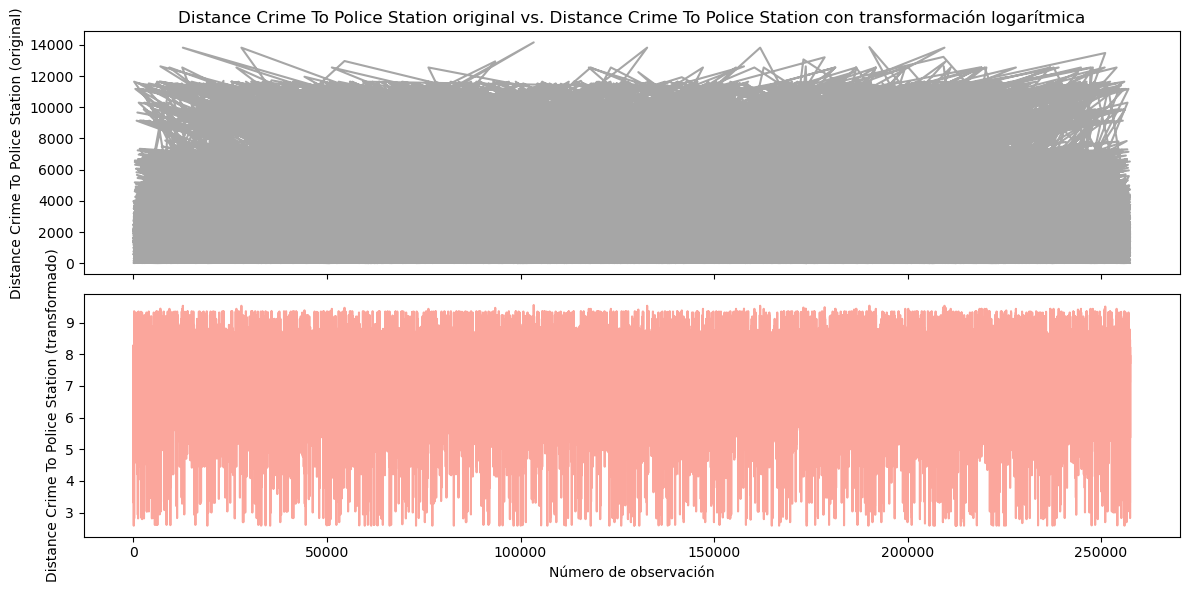

In [57]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

# Primer gráfico: datos originales
axes[0].plot(df.index, df['Distance Crime To Police Station'], alpha=0.7, color='gray')
axes[0].set_ylabel('Distance Crime To Police Station (original)')
axes[0].set_title('Distance Crime To Police Station original vs. Distance Crime To Police Station con transformación logarítmica')

# Segundo gráfico: datos imputados
axes[1].plot(df_transformed.index, df_transformed['Distance Crime To Police Station'], alpha=0.7, color='salmon')
axes[1].set_ylabel('Distance Crime To Police Station (transformado)')
axes[1].set_xlabel('Número de observación')

plt.tight_layout()
plt.show()

In [58]:
df_for_outliers = df_transformed[['Distance Crime To Police Station']]

In [59]:
Q1 = df_for_outliers.quantile(0.25)
Q3 = df_for_outliers.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (df_for_outliers < (Q1 - 1.5 * IQR)) | (df_for_outliers > (Q3 + 1.5 * IQR))
print(f"Outliers\nDistance Crime To Police Station: <{Q1['Distance Crime To Police Station'] - 1.5 * IQR['Distance Crime To Police Station']:.02f} o >{Q3['Distance Crime To Police Station'] + 1.5 * IQR['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <6.03 o >8.91


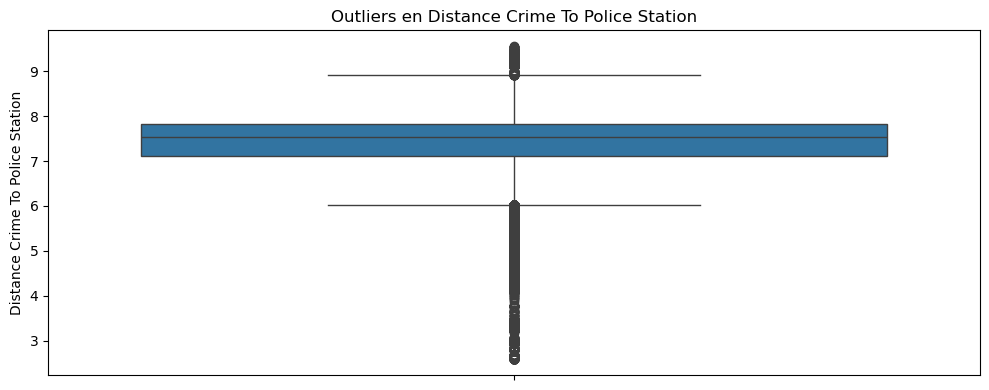

In [60]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_for_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

In [61]:
# Método basado en desviación estándar
mean = df_for_outliers.mean()
std = df_for_outliers.std()
# std = df_transformed.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_for_outliers < (mean - 3 * std)) | (df_for_outliers > (mean + 3 * std))

print(f"Outliers\nDistance Crime To Police Station: <{mean['Distance Crime To Police Station'] - 3 * std['Distance Crime To Police Station']:.02f} o >{mean['Distance Crime To Police Station'] + 3 * std['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <5.38 o >9.45


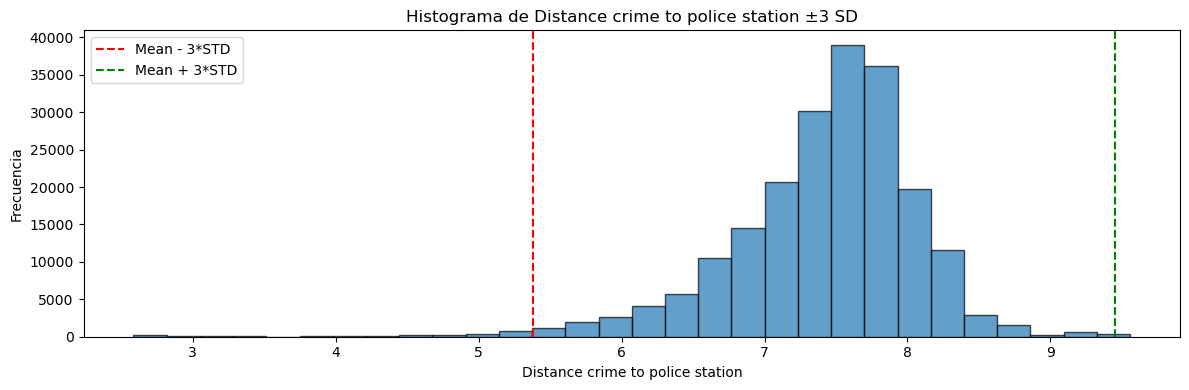

In [62]:
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean[varname] - 3*std[varname], color='red', linestyle='--', label='Mean - 3*STD')
    ax.axvline(mean[varname] + 3*std[varname], color='green', linestyle='--', label='Mean + 3*STD')
    ax.set_xlabel(varname.capitalize())
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Histograma de {varname.capitalize()} ±3 SD')
    ax.legend()

fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_for_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

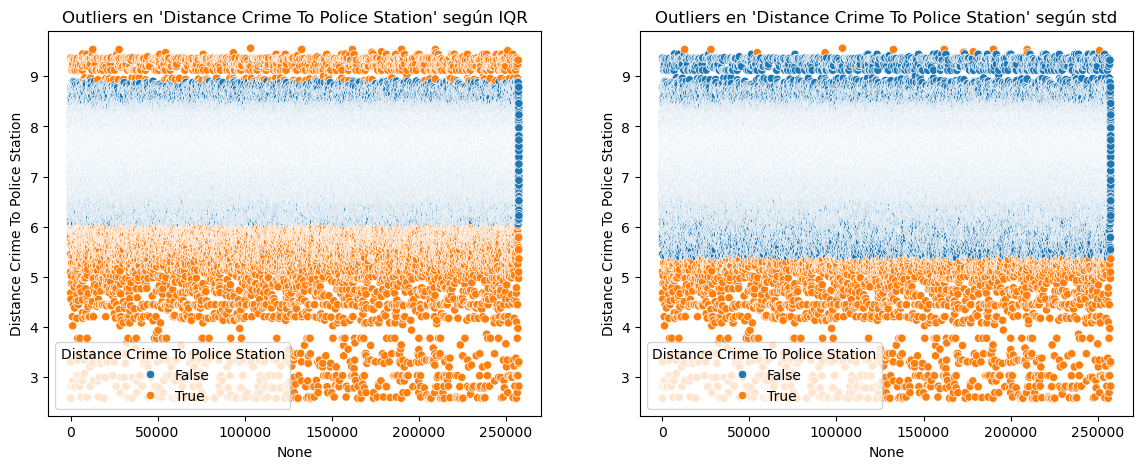

In [63]:
# Visualización con scatterplot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_iqr['Distance Crime To Police Station'], ax=ax[0])
ax[0].set_title("Outliers en 'Distance Crime To Police Station' según IQR")
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_std['Distance Crime To Police Station'], ax=ax[1])
ax[1].set_title("Outliers en 'Distance Crime To Police Station' según std")
plt.show()

In [64]:
df_transformed[outliers_std['Distance Crime To Police Station']==True]["Arrest"].value_counts()

Arrest
False    1957
True      579
Name: count, dtype: int64

In [65]:
df_no_outliers = df_transformed[~outliers_std.any(axis=1)]
df_no_outliers.describe()

,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,203475.000000,203475.000000,203475.000000,203475.000000,2.034750e+05,2.034750e+05,203475.000000,203475.000000,203475.000000,203475.000000
mean,128939.259305,1157.158752,23.207367,36.179339,1.165249e+06,1.887717e+06,41.847480,-87.669038,11.341796,7.450139
std,74732.374218,709.260377,13.934950,21.580178,1.618173e+04,3.152226e+04,0.086680,0.051376,7.087380,0.593781
min,0.000000,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,1.000000,5.379825
25%,64186.500000,533.000000,10.000000,22.000000,1.153900e+06,1.860531e+06,41.772655,-87.705488,5.000000,7.128718
50%,128610.000000,1034.000000,23.000000,32.000000,1.167089e+06,1.894486e+06,41.866255,-87.656973,10.000000,7.533809
75%,193890.000000,1732.000000,34.000000,53.000000,1.176650e+06,1.910455e+06,41.910064,-87.630560,17.000000,7.832032
max,258610.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,9.443448


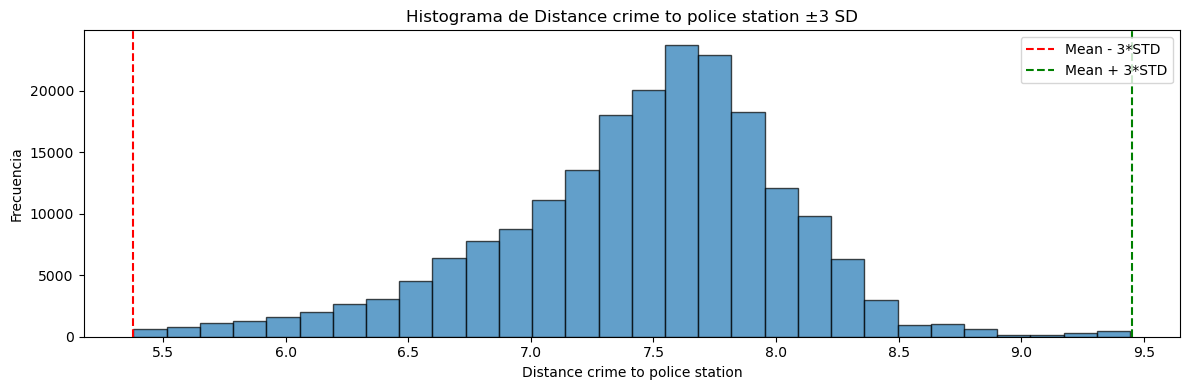

In [66]:
fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_no_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

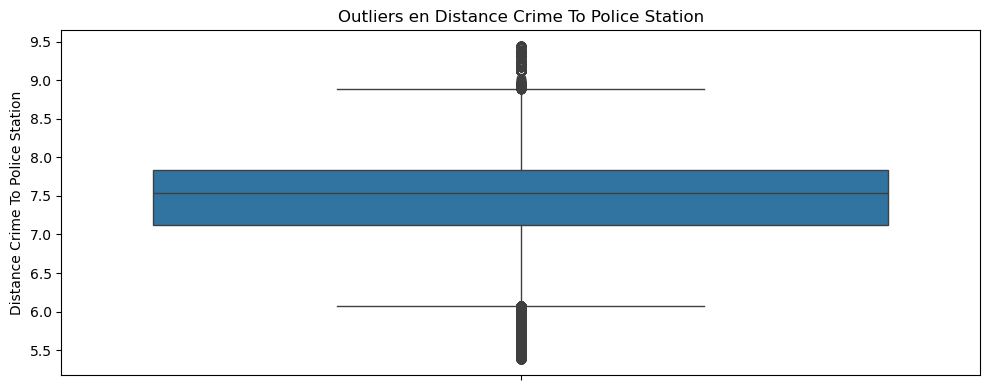

In [67]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_no_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

## Codificación (encoding)



In [85]:
# Convertimos columnas del dataset del crimen al tipo correcto
df_no_outliers['IUCR'] = df_no_outliers['IUCR'].astype('category').copy()
df_no_outliers['Primary Type'] = df_no_outliers['Primary Type'].astype('category').copy()
df_no_outliers['Location Description'] = df_no_outliers['Location Description'].astype('category').copy()
df_no_outliers['FBI Code'] = df_no_outliers['FBI Code'].astype('category').copy()
df_no_outliers['Arrest'] = df_no_outliers['Arrest'].astype('category').copy()
df_no_outliers['Domestic'] = df_no_outliers['Domestic'].astype('category').copy()
df_no_outliers['Crime District'] = df_no_outliers['Crime District'].astype('category').copy()
df_no_outliers['Nearest Police Station District'] = df_no_outliers['Nearest Police Station District'].astype('category').copy()
df_no_outliers['Nearest Police Station District Name'] = df_no_outliers['Nearest Police Station District Name'].astype('category').copy()
df_no_outliers['Season'] = df_no_outliers['Season'].astype('category').copy()
df_no_outliers['Day'] = df_no_outliers['Day'].astype('category').copy()
df_no_outliers['Day Time'] = df_no_outliers['Day Time'].astype('category').copy()

In [86]:
df_no_outliers.describe(include='category')

,IUCR,Primary Type,Location Description,Arrest,Domestic,FBI Code,Crime District,Nearest Police Station District,Nearest Police Station District Name,Season,Day,Day Time
count,203475,203475,203475,203475,203475,203475,203475,203475,203475,203475,203475,203475
unique,332,31,124,2,2,26,23,23,23,4,7,4
top,0486,THEFT,STREET,False,False,06,8,3,Grand Crossing,Summer,Monday,Afternoon
freq,16125,47784,54911,175620,166123,48415,13664,19035,19035,55476,30058,63337


### Cyclic Encoding
Transforma variables cíclicas (como horas del día o meses del año) en coordenadas en un círculo.


In [87]:
df_no_outliers["Day_num"] = df_no_outliers["Day"].map({
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4, "Thursday": 5, "Friday": 6, "Saturday": 7
}).astype(int)

In [88]:
df_no_outliers["Day_sin"] = np.sin(2 * np.pi * df_no_outliers["Day_num"] / 7)

### One-Hot encoding
Crea una columna binaria (0/1) para cada categoría.


In [89]:
df_no_outliers = df_no_outliers.reset_index()

In [90]:
# Inicializar el OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

# Fit + transform
encoded_array = ohe.fit_transform(df_no_outliers[["Season"]])  # Ojo! me devuelve un array de NumPy
columns=ohe.get_feature_names_out(["Season"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(["Season"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe = df_no_outliers.join(encoded_df)  # opcional: .drop(columns=["sex"])

In [91]:
# Inicializar el OneHotEncoder
ohe_2 = OneHotEncoder(sparse_output=False)

# Fit + transform
encoded_array = ohe_2.fit_transform(df_ohe[["Day Time"]])  # Ojo! me devuelve un array de NumPy
columns=ohe_2.get_feature_names_out(["Day Time"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe_2.get_feature_names_out(["Day Time"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe_2 = df_ohe.join(encoded_df)  # opcional: .drop(columns=["sex"])

### Label encoding

Asigna un número entero arbitrario a cada categoría (de la variable target).

In [92]:
df_label = df_ohe_2.copy()

In [93]:
df_label["Arrest_tag"] = df_label["Arrest"].astype(int)
df_label["Domestic_tag"] = df_label["Domestic"].astype(int)

In [94]:
df_label = df_label.drop(columns=["Season", "Day", "Day_num", "Day Time", "index", "Arrest", "Domestic"])

### Frequency Encoding
Sustituye cada categoría por su frecuencia de aparición.


In [95]:
df_freq = df_label.copy()

In [96]:
# 4. Frequency Encoding

freq_encoding = df_freq["IUCR"].value_counts(normalize=True)
df_freq["IUCR_freq"] = df_freq["IUCR"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Primary Type"].value_counts(normalize=True)
df_freq["Primary_Type_freq"] = df_freq["Primary Type"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Location Description"].value_counts(normalize=True)
df_freq["Location_Description_freq"] = df_freq["Location Description"].map(freq_encoding).astype(float)

freq_encoding = df_freq["FBI Code"].value_counts(normalize=True)
df_freq["FBI_Code_freq"] = df_freq["FBI Code"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Crime District"].value_counts(normalize=True)
df_freq["Crime_District_freq"] = df_freq["Crime District"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Nearest Police Station District"].value_counts(normalize=True)
df_freq["Nearest_Police_Station_District_freq"] = df_freq["Nearest Police Station District"].map(freq_encoding).astype(float)

freq_encoding = df_freq["Nearest Police Station District Name"].value_counts(normalize=True)
df_freq["Nearest_Police_Station_District_Name_freq"] = df_freq["Nearest Police Station District Name"].map(freq_encoding).astype(float)

In [97]:
df_freq = df_freq.drop(columns=["IUCR", "Primary Type", "Location Description", "FBI Code", "Crime District", "Nearest Police Station District", "Nearest Police Station District Name"])

In [98]:
df_freq.describe()

,level_0,Unnamed: 0,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,...,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
count,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,2.034750e+05,2.034750e+05,203475.000000,203475.000000,203475.000000,...,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000,203475.000000
mean,101737.000000,128939.259305,1157.158752,23.207367,36.179339,1.165249e+06,1.887717e+06,41.847480,-87.669038,7.450139,...,0.284477,0.136896,0.183570,0.040021,0.126921,0.132409,0.117737,0.048339,0.052578,0.052578
std,58738.317349,74732.374218,709.260377,13.934950,21.580178,1.618173e+04,3.152226e+04,0.086680,0.051376,0.593781,...,0.451166,0.343739,0.387134,0.028889,0.076650,0.105204,0.077399,0.010930,0.022535,0.022535
min,0.000000,0.000000,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.379825,...,0.000000,0.000000,0.000000,0.000005,0.000005,0.000005,0.000010,0.000054,0.013535,0.013535
25%,50868.500000,64186.500000,533.000000,10.000000,22.000000,1.153900e+06,1.860531e+06,41.772655,-87.705488,7.128718,...,0.000000,0.000000,0.000000,0.010036,0.065104,0.023295,0.055270,0.039568,0.035675,0.035675
50%,101737.000000,128610.000000,1034.000000,23.000000,32.000000,1.167089e+06,1.894486e+06,41.866255,-87.656973,7.533809,...,0.000000,0.000000,0.000000,0.052935,0.110716,0.119671,0.083946,0.051815,0.049053,0.049053
75%,152605.500000,193890.000000,1732.000000,34.000000,53.000000,1.176650e+06,1.910455e+06,41.910064,-87.630560,7.832032,...,1.000000,0.000000,0.000000,0.062204,0.178607,0.269866,0.148608,0.054252,0.066200,0.066200
max,203474.000000,258610.000000,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448,...,1.000000,1.000000,1.000000,0.079248,0.234840,0.269866,0.237941,0.067153,0.093550,0.093550


In [99]:
df_freq.dtypes

level_0                                        int64
Unnamed: 0                                     int64
Beat                                           int64
Ward                                           int64
Community Area                                 int64
X Coordinate                                 float64
Y Coordinate                                 float64
Latitude                                     float64
Longitude                                    float64
Distance Crime To Police Station             float64
Day_sin                                      float64
Season_Autumn                                float64
Season_Spring                                float64
Season_Summer                                float64
Season_Winter                                float64
Day Time_Afternoon                           float64
Day Time_Early Morning                       float64
Day Time_Morning                             float64
Day Time_Night                               f

## Salvamos en un archivo

In [104]:
df_freq.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv", index=False)

## Eliminamos duplicados de la clase mayoritaria (Arrest_tag==0)

In [110]:
df_csv = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")

In [111]:
df_csv.duplicated().sum()

np.int64(0)

In [112]:
df_csv[df_csv.duplicated()]["Arrest_tag"].value_counts()

Series([], Name: count, dtype: int64)

In [113]:
df_csv["Arrest_tag"].value_counts()

Arrest_tag
0    175620
1     27855
Name: count, dtype: int64

In [114]:
df_csv["Arrest_tag"].value_counts(normalize=True).round(4) * 100

Arrest_tag
0    86.31
1    13.69
Name: proportion, dtype: float64

In [115]:
# 1️⃣ identificar las filas duplicadas (ajustá subset si querés definir tus columnas)
dup_mask = df_csv.duplicated()

# 2️⃣ obtener los índices de las duplicadas con Arrest_tag == 0
idx_drop = df_csv.index[dup_mask & (df_csv["Arrest_tag"] == 0)]

# 3️⃣ eliminar esas filas
df_csv = df_csv.drop(index=idx_drop).reset_index(drop=True)


In [116]:
dup_mask.sum()

np.int64(0)

In [117]:
df_csv.duplicated().sum()

np.int64(0)

In [118]:
df_csv[df_csv.duplicated()]["Arrest_tag"].value_counts()

Series([], Name: count, dtype: int64)

In [119]:
df_csv["Arrest_tag"].value_counts()

Arrest_tag
0    175620
1     27855
Name: count, dtype: int64

In [120]:
df_csv["Arrest_tag"].value_counts(normalize=True).round(4) * 100

Arrest_tag
0    86.31
1    13.69
Name: proportion, dtype: float64